# CIFAR-100 - EfficientNet-B0-Like From Scratch

This notebook trains a custom EfficientNet-B0-like classifier on CIFAR-100 using the shared project utilities. It serves as the main from-scratch EfficientNet baseline before scaling up to the B3-like experiment.

## Experiment Summary

| Item | Setting |
|------|---------|
| Dataset | CIFAR-100 |
| Input size | 224 x 224 |
| Initialization | From scratch |
| Model | Custom EfficientNet-B0-like network |
| Parameters | 4,135,648 |
| Training | SGD with Nesterov momentum and OneCycleLR stepped per batch |
| Regularization | Label smoothing, MixUp, stochastic depth, SE blocks, dropout |
| Checkpoints | `../checkpoint/efficient_net_v5_onecycle150_100_*` |
| Stored output result | Best validation: 77.31%; test: 77.83% |

## Reproducibility Note

The saved output cells are from a 150-epoch run, while the current training cell sets `EPOCHS = 120`. Rerunning the notebook from the current code will not exactly reproduce the stored training log unless the epoch count is intentionally restored.

## Imports

Load PyTorch, AMP, optimizer/scheduler components, and the shared project helpers for CIFAR-100 data loading, training, checkpointing, and plotting.

In [1]:
import sys

from ipykernel.kernelapp import kernel_flags
from torch.ao.pruning import scheduler

sys.path.append('..')

import torch
import torch.nn as nn
import torchvision.models as models
from torch import optim
from torch.amp import GradScaler

from utils.dataset import get_cifar100_dataloaders, CIFAR100_CLASSES
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch

## Device Setup

Select CUDA when it is available and enable cuDNN benchmarking for faster convolution kernels on fixed-size image batches.

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')

Using device: cuda


## Data

Build CIFAR-100 train, validation, and test loaders with `batch_size=128`. Images are resized to `224 x 224` and normalized with ImageNet statistics so this scratch baseline is comparable with the project's high-resolution CIFAR-100 runs.

The shared loader keeps an 80/20 split from the official 50,000-image training set and evaluates on the official 10,000-image test set.

In [3]:
batch_size = 128

trainloader, valloader, testloader = get_cifar100_dataloaders(
    batch_size=batch_size,
    num_workers=4,
    img_size=224,
    use_imagenet_stats=True,
)
print(f'Train: {len(trainloader)} | Val: {len(valloader)} | Test: {len(testloader)}')

C:\Users\asmit\PycharmProjects\CIFAR_10\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 313 | Val: 79 | Test: 79


## Model Architecture

Define the EfficientNet-style model from small reusable blocks before instantiating it. The architecture uses squeeze-and-excitation attention, depthwise separable convolutions, MBConv blocks, stochastic depth, and dropout before the CIFAR-100 classifier.

In [4]:
class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation block.
    se_ratio=0.25 is applied to the *block input* channels (pre-expansion),
    matching the official EfficientNet paper (Tan et al., 2019).
    """
    def __init__(self, expanded_channels, block_input_channels, se_ratio=0.25):
        super(SEBlock, self).__init__()
        squeezed = max(1, int(block_input_channels * se_ratio))
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(expanded_channels, squeezed, bias=True),
            nn.SiLU(),
            nn.Linear(squeezed, expanded_channels, bias=True),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.se(x).view(x.size(0), x.size(1), 1, 1)


### Depthwise Separable Block

Wrap depthwise convolution, batch normalization, SiLU activation, SE attention, and pointwise projection into one reusable block. The SE squeeze width is based on the block input channels, matching the EfficientNet paper.

In [5]:
class DepthwiseSeparableConv(nn.Module):
    """
    Depthwise conv -> BN -> SiLU -> SE -> Pointwise conv -> BN.
    SE ratio is applied to block_input_channels (pre-expansion), per paper.
    """
    def __init__(self, in_channels, out_channels, block_input_channels,
                 kernel_size=3, stride=1, se_ratio=0.25):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Sequential(
            nn.Conv2d(
                in_channels, in_channels,
                kernel_size, stride,
                padding=kernel_size // 2,
                groups=in_channels,
                bias=False
            ),
            nn.BatchNorm2d(in_channels),
            nn.SiLU()
        )

        self.se = SEBlock(in_channels, block_input_channels, se_ratio)

        self.pointwise = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        x = self.depthwise(x)
        x = self.se(x)
        x = self.pointwise(x)
        return x


### MBConv and Stochastic Depth

Define drop-path regularization and the mobile inverted bottleneck block. Residual connections are used only when stride and channel count allow an identity shortcut.

In [6]:
class StochasticDepth(nn.Module):
    """Drop Path (Stochastic Depth) regularization per block."""
    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if not self.training or self.drop_prob == 0.0:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor = torch.floor(random_tensor + keep_prob)
        return x * random_tensor / keep_prob


class MBConv(nn.Module):
    """
    Mobile Inverted Bottleneck Convolution block.
      t=1  -> MBConv1: no expansion (used in Stage 1 only)
      t=6  -> MBConv6: 6x expansion (used in Stages 2-7)
    Stochastic Depth is applied to the residual branch during training.
    """
    def __init__(self, in_channels, out_channels, stride=1,
                 kernel_size=3, t=6, drop_path_rate=0.0):
        super(MBConv, self).__init__()
        expanded = in_channels * t

        # Expansion phase (identity when t=1, i.e. MBConv1)
        if t > 1:
            self.expansion = nn.Sequential(
                nn.Conv2d(in_channels, expanded, kernel_size=1, bias=False),
                nn.BatchNorm2d(expanded),
                nn.SiLU()
            )
        else:
            self.expansion = nn.Identity()

        self.depthwise = DepthwiseSeparableConv(
            in_channels=expanded,
            out_channels=out_channels,
            block_input_channels=in_channels,  # SE squeezed on pre-expansion channels
            kernel_size=kernel_size,
            stride=stride,
        )

        self.use_residual = (stride == 1 and in_channels == out_channels)
        self.stochastic_depth = StochasticDepth(drop_path_rate)

    def forward(self, x):
        identity = x
        out = self.expansion(x)
        out = self.depthwise(out)
        if self.use_residual:
            out = self.stochastic_depth(out)
            out = out + identity
        return out


### EfficientNet-B0-Like Network

Assemble the B0-like stage schedule with 16 MBConv blocks, a 1280-channel head, global pooling, dropout, and a 100-class linear classifier.

In [7]:
class EfficientNet(nn.Module):
    """
    EfficientNet-B0-like architecture, corrected to match the paper:
      - Stage 1 uses MBConv1 (t=1, no expansion channel inflation)
      - SE ratio = 0.25 applied to block input channels (pre-expansion)
      - Stochastic Depth linearly scaled 0.0 -> drop_path_rate across all blocks
      - Head Dropout(p=0.2) before classifier
    """
    def __init__(self, num_classes=100, drop_path_rate=0.2, dropout_rate=0.2):
        super(EfficientNet, self).__init__()

        # Stage config: (num_blocks, in_ch, out_ch, kernel, stride, t)
        stage_cfg = [
            (1, 32,  16,  3, 1, 1),   # Stage 1: MBConv1 (t=1, no expansion)
            (2, 16,  24,  3, 2, 6),   # Stage 2: MBConv6
            (2, 24,  40,  5, 2, 6),   # Stage 3
            (3, 40,  80,  3, 2, 6),   # Stage 4
            (3, 80,  112, 5, 1, 6),   # Stage 5
            (4, 112, 192, 5, 2, 6),   # Stage 6
            (1, 192, 320, 3, 1, 6),   # Stage 7
        ]

        total_blocks = sum(cfg[0] for cfg in stage_cfg)
        block_idx = 0

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU()
        )

        # Build all stages dynamically
        stages = []
        for (num_blocks, in_ch, out_ch, k, s, t) in stage_cfg:
            layers = []
            for i in range(num_blocks):
                dp_rate = drop_path_rate * block_idx / total_blocks
                layers.append(MBConv(
                    in_channels=in_ch if i == 0 else out_ch,
                    out_channels=out_ch,
                    stride=s if i == 0 else 1,
                    kernel_size=k,
                    t=t,
                    drop_path_rate=dp_rate,
                ))
                block_idx += 1
            stages.append(nn.Sequential(*layers))

        self.stages = nn.Sequential(*stages)

        # Head
        self.head = nn.Sequential(
            nn.Conv2d(320, 1280, kernel_size=1, bias=False),
            nn.BatchNorm2d(1280),
            nn.SiLU()
        )

        # Pooling + Dropout + Classifier
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(1280, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stages(x)
        x = self.head(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.classifier(x)
        return x


### Model Summary

Instantiate the model on the selected device and print the architecture plus parameter count before configuring the actual training run.

In [8]:
model = EfficientNet().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

EfficientNet(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
  )
  (stages): Sequential(
    (0): Sequential(
      (0): MBConv(
        (expansion): Identity()
        (depthwise): DepthwiseSeparableConv(
          (depthwise): Sequential(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU()
          )
          (se): SEBlock(
            (se): Sequential(
              (0): AdaptiveAvgPool2d(output_size=1)
              (1): Flatten(start_dim=1, end_dim=-1)
              (2): Linear(in_features=32, out_features=8, bias=True)
              (3): SiLU()
              (4): Linear(in_features=8, out_features=32, bias=True)
              (5): Sigmoid()
  

## Training Configuration

Re-initialize the model for training, then configure the loss, AMP scaler, SGD optimizer, OneCycleLR schedule, and best/last checkpoint paths.

The visible code currently uses `EPOCHS = 120`; the stored training output below came from the `efficient_net_v5_onecycle150_100` checkpoint run.

In [9]:
# ── LR Tuning: OneCycleLR ────────────────────────────────────────────────
# Problem: CosineAnnealingLR decays LR monotonically → val loss plateaus
#          when LR becomes very small, the model stops improving.
# Fix: OneCycleLR uses a single aggressive cycle:
#   Phase 1 (pct_start): LR warms up from max_lr/div_factor → max_lr
#   Phase 2: LR anneals from max_lr → max_lr / final_div_factor (cosine)
# Benefits: stronger regularisation via LR annealing, avoids plateau.
#
EPOCHS = 120
STEPS_PER_EPOCH = len(trainloader)  # 625 batches

model = EfficientNet().to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler    = GradScaler('cuda')

optimizer = optim.SGD(
    model.parameters(),
    lr=0.05,          # will be overridden by OneCycleLR
    momentum=0.9,
    weight_decay=5e-4,
    nesterov=True,
)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.1,              # peak LR (2× previous starting LR)
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    pct_start=0.10,           # 10% warmup
    anneal_strategy='cos',
    div_factor=10.0,         # initial_lr = max_lr / 10  = 0.01
    final_div_factor=1e4,    # min_lr    = initial_lr / 1e4 = 1e-6
)

# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=120, eta_min=1e-5)

MODEL_NAME = 'efficient_net_v5_onecycle150_100'
checkpoint = ModelCheckpoint(
    model,
    checkpoint_path=f'../checkpoint/{MODEL_NAME}_last.pth',
    best_model_path=f'../checkpoint/{MODEL_NAME}_best.pth',
    mode='max',
    verbose=True,
)

## Training

Run the shared `fit` loop with MixUp and label smoothing for regularization. `step_scheduler_per_batch=True` is required because `OneCycleLR` expects one scheduler step per batch.

In [10]:
train_losses, val_losses, val_accs = fit(
    model, trainloader, valloader, criterion,
    optimizer, scheduler, scaler, device,
    EPOCHS, checkpoint,
    mixup_alpha=0.2,              # mild MixUp for extra regularization
    step_scheduler_per_batch=True, # OneCycleLR steps every batch
    log=True,
)

[RunLogger] Logging to 'logs/2357617671/'  —  run: 'efficientnet_20260524_154807'
[ModelCheckpoint] New best (max): 7.6400 — saved to ..\checkpoint\efficient_net_v5_onecycle150_100_best.pth
Epoch [ 1/150]  Train Loss: 4.3982  Val Loss: 4.0719  Val Acc: 7.64%  LR: 0.010438  Time: 63.78s
[ModelCheckpoint] New best (max): 16.2200 — saved to ..\checkpoint\efficient_net_v5_onecycle150_100_best.pth
Epoch [ 2/150]  Train Loss: 4.1145  Val Loss: 3.6926  Val Acc: 16.22%  LR: 0.011744  Time: 27.68s
[ModelCheckpoint] New best (max): 23.3700 — saved to ..\checkpoint\efficient_net_v5_onecycle150_100_best.pth
Epoch [ 3/150]  Train Loss: 3.8920  Val Loss: 3.3471  Val Acc: 23.37%  LR: 0.013892  Time: 27.55s
[ModelCheckpoint] New best (max): 31.5700 — saved to ..\checkpoint\efficient_net_v5_onecycle150_100_best.pth
Epoch [ 4/150]  Train Loss: 3.6632  Val Loss: 3.0477  Val Acc: 31.57%  LR: 0.016840  Time: 27.56s
[ModelCheckpoint] New best (max): 36.8600 — saved to ..\checkpoint\efficient_net_v5_onecycle

## Learning Curves

Plot training loss, validation loss, and validation accuracy to inspect convergence and check for overfitting.

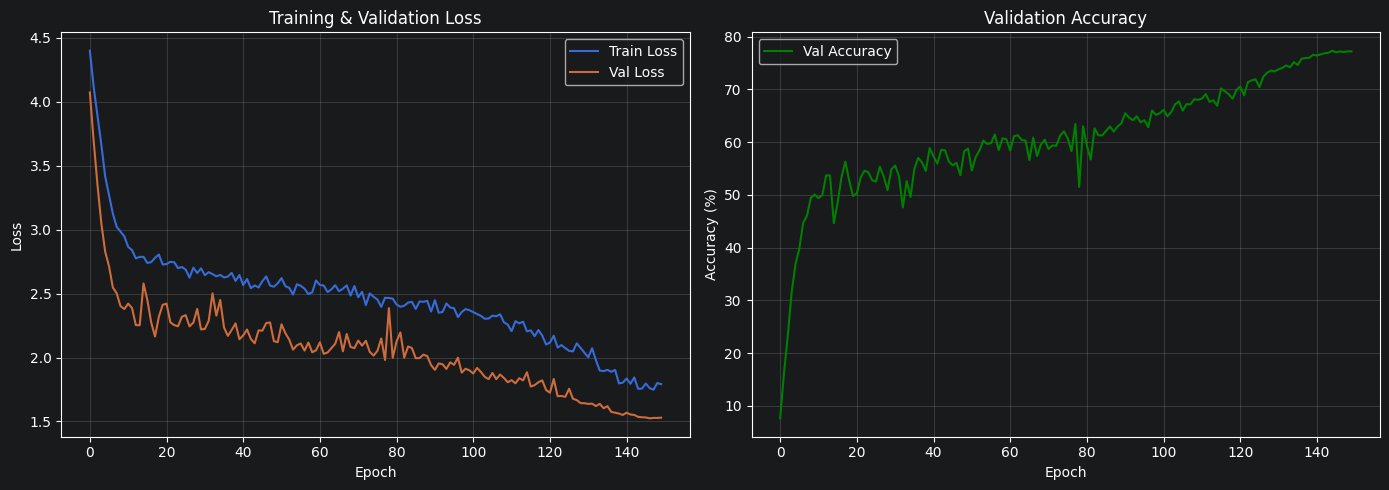

In [11]:
plot_training_curves(train_losses, val_losses, val_accs)

## Test Evaluation

Restore the best validation checkpoint, evaluate on the official CIFAR-100 test split, and print per-class accuracy sorted from strongest to weakest.

In [12]:
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, CIFAR100_CLASSES, device)
print(f'Test Accuracy: {overall_acc:.2f}%\n')

print('Per-class accuracies (best first):')
sorted_classes = sorted(per_class.items(), key=lambda x: x[1], reverse=True)
for cls, acc in sorted_classes:
    bar = '█' * int(acc / 5)
    print(f'  {cls:<20s} {acc:5.1f}%  {bar}')

[ModelCheckpoint] Restored best weights from ..\checkpoint\efficient_net_v5_onecycle150_100_best.pth (score=77.3100)
Test Accuracy: 77.83%

Per-class accuracies (best first):
  wardrobe              97.0%  ███████████████████
  road                  95.0%  ███████████████████
  pickup_truck          94.0%  ██████████████████
  skunk                 94.0%  ██████████████████
  tractor               94.0%  ██████████████████
  bicycle               93.0%  ██████████████████
  keyboard              93.0%  ██████████████████
  lawn_mower            93.0%  ██████████████████
  motorcycle            93.0%  ██████████████████
  chair                 92.0%  ██████████████████
  palm_tree             92.0%  ██████████████████
  skyscraper            92.0%  ██████████████████
  sunflower             92.0%  ██████████████████
  tank                  92.0%  ██████████████████
  apple                 91.0%  ██████████████████
  aquarium_fish         91.0%  ██████████████████
  chimpanzee           